# Solver Comparison

Comparing two solver implementations on the same physical problems:
- **explicit**: Explicit time-stepping (Ny=1)
- **fem_2d**: 2D FEM with stabilization (Ny=4, but periodic in y and therefore comparable to the 1D cases)

In [1]:
from utils import load_template, run_all_solvers, plot_solver_comparison_rho_jx, print_timing

## Inclined Slider (Air, PL EOS)

Linear converging gap with Dirichlet density BC.

<img src="./figures/Geometry_InclinedSlider.png"
     alt="Inclined slider geometry"
     width="250">

$\rightarrow$ **[YAML File](../../tests/configs/inclined_slider.yaml)**

In [2]:
template = load_template('inclined_slider')
results_inclined = run_all_solvers(template, explicit_overrides={'dt': 1e-6})

*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/inclined_slider_explicit
  - write_freq               : 1000
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 100
  - Lx                       : 0.1
  - dx                       : 0.001
  - Ny                       : 1
  - Ly                       : 0.1
  - dy                       : 0.1
  - dim                      : 1
  - bc_xW                    : ['D', 'N', 'N']
  - bc_xE                    : ['D', 'N', 'N']
  - bc_xW_D_val              : 1.1853
  - bc_xE_D_val              : 1.1853
  - bc_yS                    : ['P', 'P', 'P']
  - bc_yN         

/home/qd5728/fem_taylor_hood/GaPFlow/doc/tutorials/utils/plotting.py:160: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


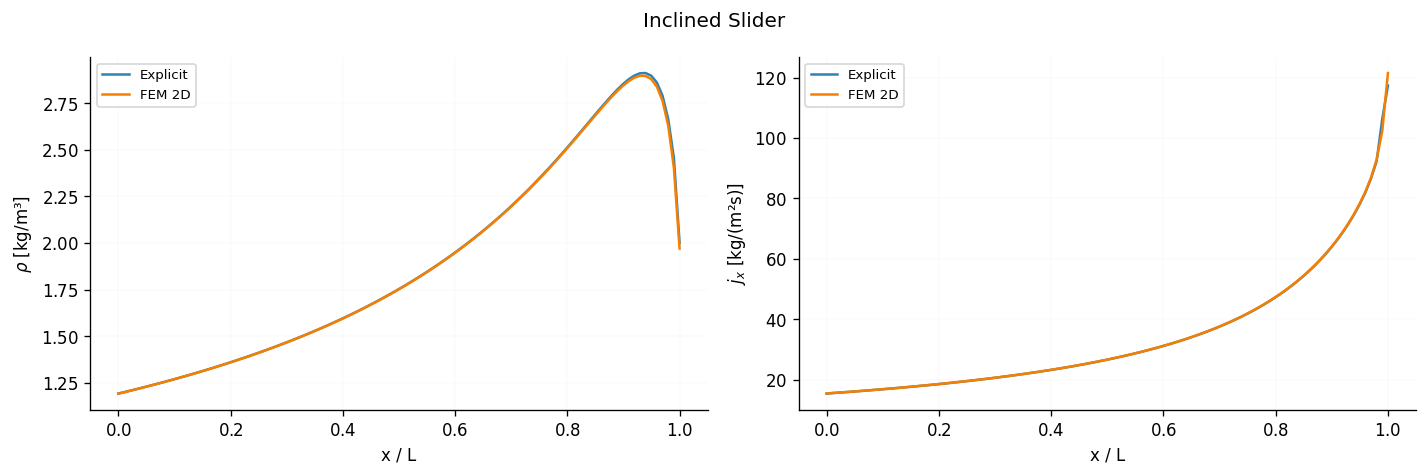

Timing:
  explicit   149.12 s
  solver_fem   3.97 s


In [3]:
plot_solver_comparison_rho_jx(results_inclined, 'Inclined Slider')
print_timing(results_inclined)

## Journal Bearing (Oil, DH EOS)

Cosine gap profile with fully periodic BC.

<img src="./figures/Geometry_JournalBearing.png"
     alt="Journal bearing geometry"
     width="250">

$\rightarrow$ **[YAML File](../../tests/configs/journal_bearing.yaml)**

In [4]:
template = load_template('journal_bearing')
results_journal = run_all_solvers(template, 
                                   explicit_overrides={'dt': 1e-10, 'adaptive': 1, 'CFL': 0.1})

*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/journal_bearing_explicit
  - write_freq               : 1000
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 100
  - dx                       : 1e-05
  - Lx                       : 0.001
  - Ny                       : 1
  - dy                       : 1e-05
  - Ly                       : 1e-05
  - dim                      : 1
  - bc_xW                    : ['P', 'P', 'P']
  - bc_xE                    : ['P', 'P', 'P']
  - bc_yS                    : ['P', 'P', 'P']
  - bc_yN                    : ['P', 'P', 'P']
- geometry:
  - U_bot                    

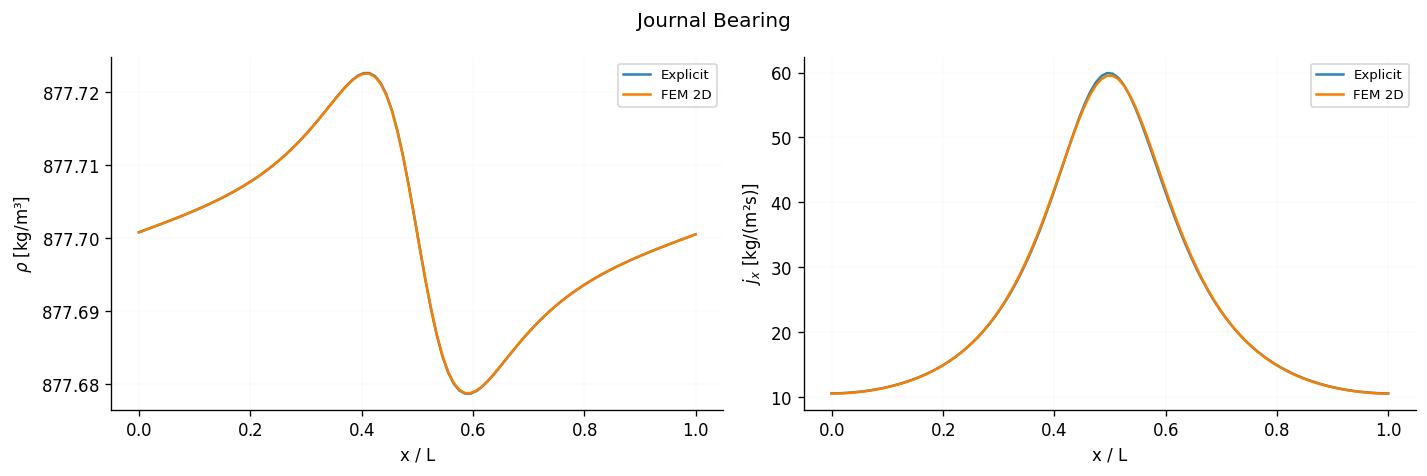

Timing:
  explicit   239.89 s
  solver_fem   3.16 s


In [5]:
plot_solver_comparison_rho_jx(results_journal, 'Journal Bearing')
print_timing(results_journal)

## Parabolic Slider (Oil, DH EOS)

Parabolic gap profile with Dirichlet density BC.

<img src="./figures/Geometry_ParabolicSlider13.png"
     alt="Parabolic slider geometry"
     width="250">

$\rightarrow$ **[YAML File](../../tests/configs/parabolic_slider.yaml)**

In [8]:
template = load_template('parabolic_slider')
results_parabolic = run_all_solvers(template, 
                                     explicit_overrides={'dt': 1e-10, 'adaptive': 1, 'CFL': 0.45},
                                     rho_bc=850.0)

*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/parabolic_slider_explicit
  - write_freq               : 1000
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 100
  - Lx                       : 0.0762
  - dx                       : 0.0007620000000000001
  - Ny                       : 1
  - Ly                       : 0.004
  - dy                       : 0.004
  - dim                      : 1
  - bc_xW                    : ['D', 'N', 'N']
  - bc_xE                    : ['D', 'N', 'N']
  - bc_xW_D_val              : 850.0
  - bc_xE_D_val              : 850.0
  - bc_yS                    : ['P', 'P', '

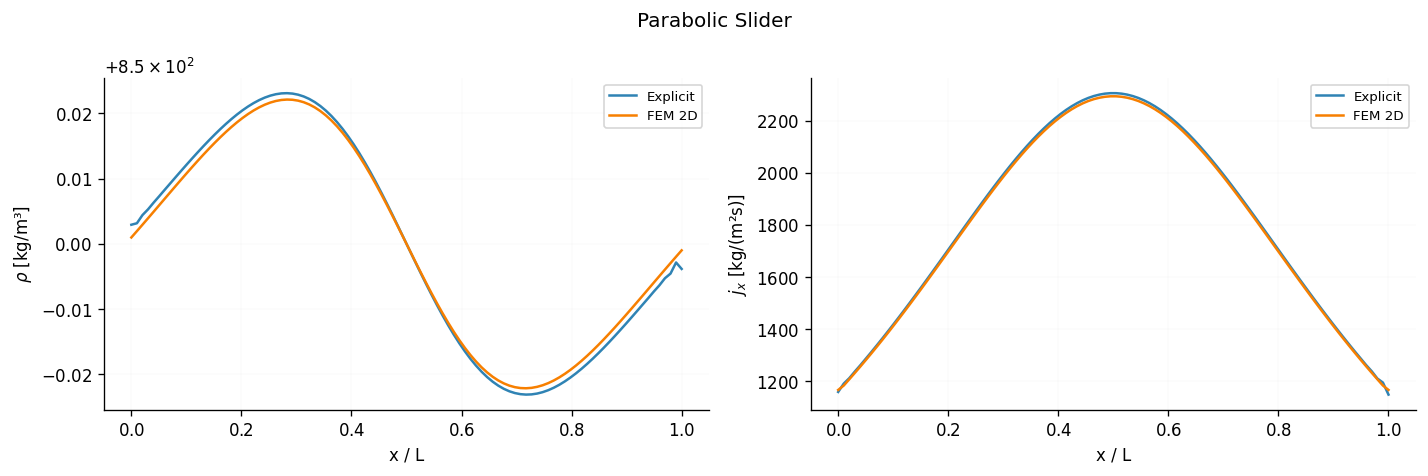

Timing:
  explicit    43.38 s
  solver_fem   6.67 s


In [9]:
plot_solver_comparison_rho_jx(results_parabolic, 'Parabolic Slider')
print_timing(results_parabolic)